In [1]:
# Added for the public reproduction package: load the pseudonymized CSV instead of the
# private spreadsheet and write any output files to ../output/notebooks/. See repro_data.py.
import repro_data


Resumen descriptivo de SUS UX por tratamiento:

tratamiento                              nombre_tratamiento  n     media  desvio_std  minimo  maximo    q1  mediana     q3
          1               Treatment 1: single auth (mobile) 17 76.764706   15.977638    42.5    97.5 72.50    77.50 85.000
          2 Treatment 2: 2-of-2, init desktop / auth mobile 17 62.647059   22.988968    17.5    92.5 45.00    72.50 77.500
          3 Treatment 3: 2-of-2, init mobile / auth desktop 18 73.888889   12.897281    50.0    95.0 65.00    71.25 84.375
          4      Treatment 4: single auth (desktop web app) 15 77.666667   11.435638    55.0    92.5 73.75    77.50 85.000
      Total                          Todos los tratamientos 67 72.611940   17.229692    17.5    97.5 65.00    77.50 85.000

Guardado como resumen_tratamientos.xlsx
Guardado como tabla_tratamientos.tex
Guardado como boxplot_tratamientos.png
Guardado como boxplot_tratamientos.pdf


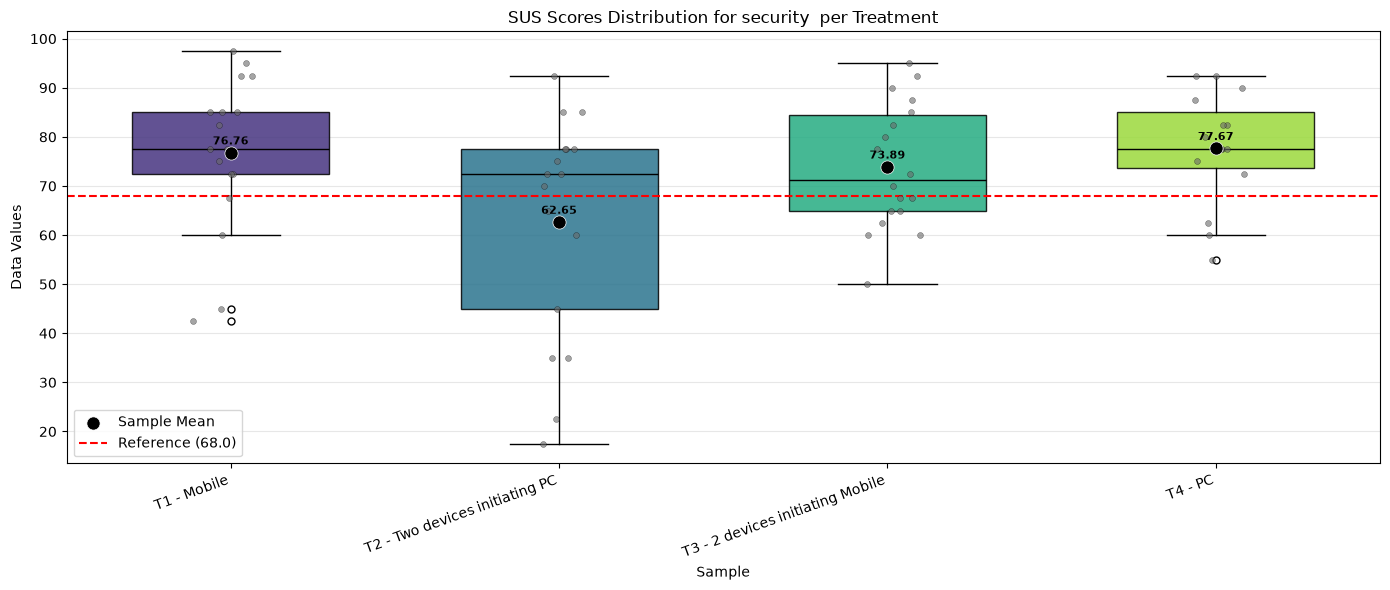

In [2]:
"""
Análisis de resultados del experimento: Wallet-pattern.xlsx

Calcula la media del puntaje SUS UX para cada uno de los 4 tratamientos
y genera un boxplot con 6 grupos: T1, T2, T3, T4, T1+T4 (un solo
dispositivo) y T2+T3 (dos dispositivos).

  Treatment 1: single spend authorization from a mobile device
  Treatment 2: 2-of-2 spend authorization iniciando la transacción desde una
               extensión de billetera en el navegador de escritorio y
               autorizando en un dispositivo móvil
  Treatment 3: 2-of-2 spend authorization iniciando la transacción desde el
               dispositivo móvil y autorizando en la aplicación de
               navegador de escritorio
  Treatment 4: single spend authorization from the desktop browser web
               application

Datos: hoja "Datos cuanti"
  - Columna "Grupo": número de tratamiento (1 a 4)
  - Columna "SUS UX": puntaje SUS (0-100) ya calculado para cada respondente
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ARCHIVO = "Wallet-pattern-.xlsx"
HOJA = "Datos cuanti"
COL_TRATAMIENTO = "Grupo"
COL_VALOR = "SUS UX"

# Valor de referencia a marcar con la línea roja punteada en el gráfico.
# Editá este número según el benchmark que quieras mostrar (p. ej. el SUS
# promedio de la industria, un valor de un estudio anterior, etc.)
VALOR_REFERENCIA = 68

NOMBRES_TRATAMIENTOS = {
    1: "Treatment 1: single auth (mobile)",
    2: "Treatment 2: 2-of-2, init desktop / auth mobile",
    3: "Treatment 3: 2-of-2, init mobile / auth desktop",
    4: "Treatment 4: single auth (desktop web app)",
}

# Etiquetas y agrupamiento para el boxplot (en el orden en que se dibujan).
# Cada entrada define qué números de "Grupo" se combinan bajo esa etiqueta.
GRUPOS_BOXPLOT = [
    ("T1 - Mobile", [1]),
    ("T2 - Two devices initiating PC", [2]),
    ("T3 - 2 devices initiating Mobile", [3]),
    ("T4 - PC", [4]),
]

TITULO_GRAFICO = "SUS Scores Distribution for security  per Treatment"


def cargar_datos(archivo, hoja):
    import os
    if False:  # file check disabled: data comes from repro_data
        raise FileNotFoundError(
            f"No encuentro el archivo en '{archivo}'. "
            "Editá la variable ARCHIVO al principio del script con la ruta "
            "completa donde tenés guardado el Excel en tu computadora."
        )
    df = repro_data.read_datos_cuanti()
    df.columns = [str(c).strip() for c in df.columns]  # saca espacios de más en los encabezados
    return df


def calcular_estadisticos(df, col_tratamiento, col_valor, nombres):
    for col in (col_tratamiento, col_valor):
        if col not in df.columns:
            raise KeyError(
                f"No encontré la columna '{col}' en la hoja. "
                f"Las columnas disponibles son: {list(df.columns)}"
            )
    df = df[[col_tratamiento, col_valor]].rename(
        columns={col_tratamiento: "tratamiento", col_valor: "valor"}
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    df = df.dropna(subset=["tratamiento", "valor"])
    df["tratamiento"] = df["tratamiento"].astype(int)

    resumen = (
        df.groupby("tratamiento")["valor"]
        .agg(n="count", media="mean", desvio_std="std", minimo="min",
             q1=lambda x: x.quantile(0.25), mediana="median",
             q3=lambda x: x.quantile(0.75), maximo="max")
        .reset_index()
    )
    resumen["nombre_tratamiento"] = resumen["tratamiento"].map(nombres)
    resumen = resumen[["tratamiento", "nombre_tratamiento", "n", "media", "desvio_std",
                        "minimo", "maximo", "q1", "mediana", "q3"]]

    global_row = pd.DataFrame([{
        "tratamiento": "Total",
        "nombre_tratamiento": "Todos los tratamientos",
        "n": df["valor"].count(),
        "media": df["valor"].mean(),
        "desvio_std": df["valor"].std(),
        "minimo": df["valor"].min(),
        "maximo": df["valor"].max(),
        "q1": df["valor"].quantile(0.25),
        "mediana": df["valor"].median(),
        "q3": df["valor"].quantile(0.75),
    }])
    resumen = pd.concat([resumen, global_row], ignore_index=True)
    return resumen


def exportar_latex(resumen, archivo_salida="tabla_tratamientos.tex"):
    # Solo tratamientos 1-4 (sin la fila Total), en el mismo formato que ya
    # se usaba en el artículo: T1..T4, SUS(mean), SD, Min, Max, 1st Q, Median, 3rd Q
    filas = resumen[resumen["tratamiento"] != "Total"].copy()

    lineas = []
    for _, r in filas.iterrows():
        lineas.append(
            f"T{int(r['tratamiento'])}          & {r['media']:.2f}       & {r['desvio_std']:.2f} & "
            f"{r['minimo']:.1f} & {r['maximo']:.1f} & {r['q1']:.2f} & {r['mediana']:.1f}   & {r['q3']:.2f} \\\\"
        )
    filas_tex = "\n".join(lineas)

    latex = f"""\\begin{{table}}[tbp]
\\centering
\\begin{{tabular}}{{@{{}}llllllll@{{}}}}
\\toprule
Treatment & SUS (mean) & SD    & Min  & Max  & 1st Q  & Median & 3rd Q  \\\\ \\midrule
{filas_tex}
\\bottomrule
\\end{{tabular}}
\\caption{{Descriptive statistics of the SUS scores per treatment.}}
\\label{{tab:sus-score-stats-1}}
\\end{{table}}
"""
    with open(archivo_salida, "w", encoding="utf-8") as f:
        f.write(latex)
    print(f"Guardado como {archivo_salida}")


def graficar_boxplot(df, col_tratamiento, col_valor, grupos, titulo,
                      valor_referencia, archivo_salida="boxplot_tratamientos.png",
                      archivo_salida_pdf="boxplot_tratamientos.pdf"):
    """Genera un boxplot con puntos individuales (jitter) y la media marcada,
    replicando el estilo: caja de color, puntos grises superpuestos, media
    en verde con su valor anotado, y una línea roja punteada de referencia.
    """
    df = df[[col_tratamiento, col_valor]].rename(
        columns={col_tratamiento: "tratamiento", col_valor: "valor"}
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    df = df.dropna(subset=["tratamiento", "valor"])
    df["tratamiento"] = df["tratamiento"].astype(int)

    # Arma la lista de datos para cada uno de los 6 grupos del gráfico
    datos_grupos = []
    etiquetas = []
    for etiqueta, nums_tratamiento in grupos:
        valores = df.loc[df["tratamiento"].isin(nums_tratamiento), "valor"].values
        datos_grupos.append(valores)
        etiquetas.append(etiqueta)

    n_grupos = len(datos_grupos)
    colores = plt.cm.viridis(np.linspace(0.15, 0.85, n_grupos))

    fig, ax = plt.subplots(figsize=(14, 6))

    posiciones = np.arange(1, n_grupos + 1)
    caja = ax.boxplot(
        datos_grupos,
        positions=posiciones,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=1),
        flierprops=dict(marker="o", markerfacecolor="white",
                         markeredgecolor="black", markersize=5),
    )
    for parche, color in zip(caja["boxes"], colores):
        parche.set_facecolor(color)
        parche.set_alpha(0.85)

    # Puntos individuales con jitter horizontal
    rng = np.random.default_rng(0)
    for pos, valores in zip(posiciones, datos_grupos):
        jitter = rng.normal(0, 0.05, size=len(valores))
        ax.scatter(pos + jitter, valores, color="dimgray", alpha=0.6,
                   edgecolor="black", linewidth=0.3, s=18, zorder=3)

    # Media de cada grupo, marcada en negro con el valor anotado
    for pos, valores in zip(posiciones, datos_grupos):
        if len(valores) == 0:
            continue
        media = np.mean(valores)
        ax.scatter(pos, media, color="black", edgecolor="white",
                   linewidth=0.5, s=90, zorder=4,
                   label="Sample Mean" if pos == posiciones[0] else None)
        ax.annotate(f"{media:.2f}", (pos, media), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=8, color="black",
                    fontweight="bold")

    # Línea de referencia
    ax.axhline(valor_referencia, color="red", linestyle="--", linewidth=1.5,
               label=f"Reference ({valor_referencia:.1f})", zorder=2)

    ax.set_xticks(posiciones)
    ax.set_xticklabels(etiquetas, rotation=20, ha="right")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Data Values")
    ax.set_title(titulo)
    ax.grid(axis="y", linestyle="-", alpha=0.3)
    ax.legend(loc="lower left")

    fig.tight_layout()
    fig.savefig(archivo_salida, dpi=150)
    print(f"Guardado como {archivo_salida}")
    fig.savefig(archivo_salida_pdf)
    print(f"Guardado como {archivo_salida_pdf}")
    plt.show()


def main():
    df = cargar_datos(ARCHIVO, HOJA)
    resumen = calcular_estadisticos(df, COL_TRATAMIENTO, COL_VALOR, NOMBRES_TRATAMIENTOS)

    print("Resumen descriptivo de SUS UX por tratamiento:\n")
    print(resumen.to_string(index=False))

    resumen.to_excel("resumen_tratamientos.xlsx", index=False)
    print("\nGuardado como resumen_tratamientos.xlsx")

    exportar_latex(resumen)

    graficar_boxplot(df, COL_TRATAMIENTO, COL_VALOR, GRUPOS_BOXPLOT,
                      TITULO_GRAFICO, VALOR_REFERENCIA)


if __name__ == "__main__":
    main()

In [3]:
# Wilcoxon test- estándar de referencia de 68

import pandas as pd
from scipy.stats import wilcoxon

ARCHIVO = "Wallet-pattern-.xlsx"
HOJA = "Datos cuanti"

COL_TRATAMIENTO = "Grupo"
COL_VALOR = "SUS UX"

VALOR_REFERENCIA = 68


def cargar_datos(archivo, hoja):
    import os

    if False:  # file check disabled: data comes from repro_data
        raise FileNotFoundError(f"No encuentro {archivo}")

    df = repro_data.read_datos_cuanti()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def preparar_datos(df):

    df = df[[COL_TRATAMIENTO, COL_VALOR]].copy()

    df.columns = ["tratamiento", "sus"]

    df["tratamiento"] = pd.to_numeric(df["tratamiento"], errors="coerce")
    df["sus"] = pd.to_numeric(df["sus"], errors="coerce")

    df = df.dropna()

    df["tratamiento"] = df["tratamiento"].astype(int)

    return df


def test_vs_referencia(datos, nombre):

    diferencias = datos - VALOR_REFERENCIA

    resultado = wilcoxon(
        diferencias,
        alternative="greater", method="exact"  # exact null distribution, as in scipy<1.18 auto mode and in the paper
    )

    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print(f"N = {len(datos)}")
    print(f"Media = {datos.mean():.2f}")
    print(f"Mediana = {datos.median():.2f}")
    print(f"Valor de referencia = {VALOR_REFERENCIA}")
    print()
    print(f"Wilcoxon W = {resultado.statistic:.3f}")
    print(f"p-value    = {resultado.pvalue:.5f}")

    if resultado.pvalue < 0.05:
        print("Resultado: diferencia estadísticamente significativa.")
    else:
        print("Resultado: no se encontraron diferencias significativas.")

    print()


def main():

    df = cargar_datos(ARCHIVO, HOJA)

    df = preparar_datos(df)

    # Single-signature = tratamientos 1 y 4
    single = df[df["tratamiento"].isin([1, 4])]["sus"]

    # Multi-signature = tratamientos 2 y 3
    multi = df[df["tratamiento"].isin([2, 3])]["sus"]

    test_vs_referencia(single, "Single-signature (T1 + T4)")
    test_vs_referencia(multi, "Multi-signature (T2 + T3)")


if __name__ == "__main__":
    main()

Single-signature (T1 + T4)
N = 32
Media = 77.19
Mediana = 77.50
Valor de referencia = 68

Wilcoxon W = 434.000
p-value    = 0.00049
Resultado: diferencia estadísticamente significativa.

Multi-signature (T2 + T3)
N = 35
Media = 68.43
Mediana = 72.50
Valor de referencia = 68

Wilcoxon W = 369.000
p-value    = 0.19273
Resultado: no se encontraron diferencias significativas.



In [4]:
"""
Mann-Whitney U test: Single-sign (T1+T4) vs Multi-sign (T2+T3)

Requisitos: pandas, scipy, openpyxl
    pip install pandas scipy openpyxl --break-system-packages
"""

import pandas as pd
from scipy.stats import mannwhitneyu

# --------------------------------------------------------------------
# CONFIGURACIÓN
# --------------------------------------------------------------------
ARCHIVO = "Wallet-pattern-.xlsx"
HOJA = "Datos cuanti"
COLUMNA_GRUPO = "Grupo"

# Cambiá esto según qué puntaje quieras comparar:
# "SUS UX"        -> usabilidad
# "seguridad sus" -> percepción de seguridad (raw, -9 a 12; ver nota abajo)
COLUMNA_SCORE = "SUS UX"

# --------------------------------------------------------------------
# CARGA Y AGRUPAMIENTO
# --------------------------------------------------------------------
df = repro_data.read_datos_cuanti()

# Si comparás "seguridad sus", conviene transformarlo a la escala 0-100
# (score = (seguridad_sus + 12) * 2.5), aunque Mann-Whitney da el mismo
# resultado con o sin la transformación lineal (es invariante a
# transformaciones monótonas). Descomentar si hace falta:
# if COLUMNA_SCORE == "seguridad sus":
#     df[COLUMNA_SCORE] = (df[COLUMNA_SCORE] + 12) * 2.5

single_sign = df.loc[df[COLUMNA_GRUPO].isin([1, 4]), COLUMNA_SCORE].dropna()
multi_sign = df.loc[df[COLUMNA_GRUPO].isin([2, 3]), COLUMNA_SCORE].dropna()

print(f"Comparando '{COLUMNA_SCORE}'")
print(f"  Single-sign (T1+T4): n = {len(single_sign)}")
print(f"  Multi-sign  (T2+T3): n = {len(multi_sign)}")

# --------------------------------------------------------------------
# TEST DE MANN-WHITNEY (two-sided)
# --------------------------------------------------------------------
u_stat, p_value = mannwhitneyu(single_sign, multi_sign, alternative="two-sided")

print()
print("Resultado Mann-Whitney U (two-sided):")
print(f"  U = {u_stat:.2f}")
print(f"  p = {p_value:.5f}")

if p_value < 0.05:
    print("  -> Diferencia estadísticamente significativa (p < 0.05)")
else:
    print("  -> No hay diferencia estadísticamente significativa (p >= 0.05)")

# --------------------------------------------------------------------
# (Opcional) Estadísticos descriptivos por grupo, para el paper
# --------------------------------------------------------------------
resumen = pd.DataFrame({
    "Grupo": ["Single-sign (T1+T4)", "Multi-sign (T2+T3)"],
    "n": [len(single_sign), len(multi_sign)],
    "Media": [single_sign.mean(), multi_sign.mean()],
    "DE": [single_sign.std(), multi_sign.std()],
    "Mín": [single_sign.min(), multi_sign.min()],
    "Máx": [single_sign.max(), multi_sign.max()],
})
print()
print(resumen.to_string(index=False))

Comparando 'SUS UX'
  Single-sign (T1+T4): n = 32
  Multi-sign  (T2+T3): n = 35

Resultado Mann-Whitney U (two-sided):
  U = 718.50
  p = 0.04673
  -> Diferencia estadísticamente significativa (p < 0.05)

              Grupo  n     Media        DE  Mín  Máx
Single-sign (T1+T4) 32 77.187500 13.821296 42.5 97.5
 Multi-sign (T2+T3) 35 68.428571 19.088472 17.5 95.0


Guardado como boxplot_grupos_firma.png
Guardado como boxplot_grupos_firma.pdf


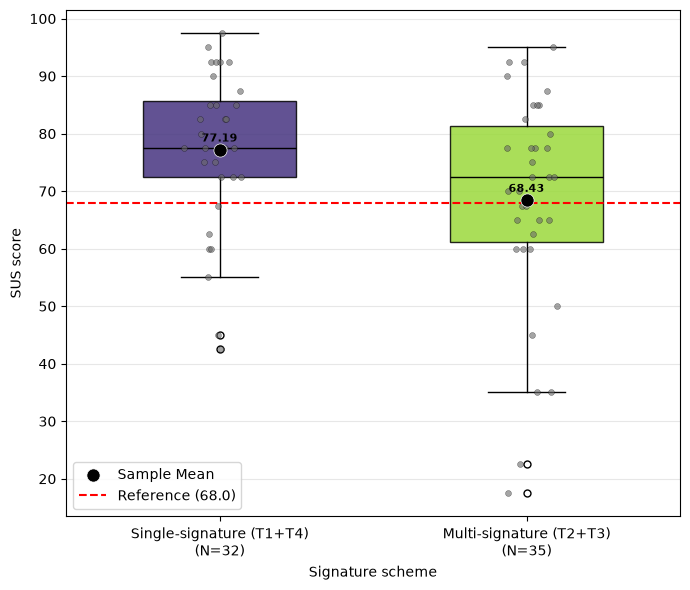

In [5]:
"""
Análisis de resultados del experimento: Wallet-pattern.xlsx

Genera un boxplot con 2 grupos, agrupando por esquema de firma
(cantidad de dispositivos), independientemente del dispositivo iniciador:

  Single-signature (T1 + T4): un solo dispositivo
    Treatment 1: single spend authorization from a mobile device
    Treatment 4: single spend authorization from the desktop browser web
                 application

  Multi-signature (T2 + T3): dos dispositivos (2-of-2)
    Treatment 2: 2-of-2 spend authorization iniciando la transacción desde una
                 extensión de billetera en el navegador de escritorio y
                 autorizando en un dispositivo móvil
    Treatment 3: 2-of-2 spend authorization iniciando la transacción desde el
                 dispositivo móvil y autorizando en la aplicación de
                 navegador de escritorio

Datos: hoja "Datos cuanti"
  - Columna "Grupo": número de tratamiento (1 a 4)
  - Columna "SUS UX": puntaje SUS (0-100) ya calculado para cada respondente
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ARCHIVO = "Wallet-pattern-.xlsx"
HOJA = "Datos cuanti"
COL_TRATAMIENTO = "Grupo"
COL_VALOR = "SUS UX"

# Valor de referencia a marcar con la línea roja punteada en el gráfico.
VALOR_REFERENCIA = 68

# Etiquetas y agrupamiento para el boxplot (en el orden en que se dibujan).
# Cada entrada define qué números de "Grupo" se combinan bajo esa etiqueta.
GRUPOS_BOXPLOT = [
    ("Single-signature (T1+T4)", [1, 4]),
    ("Multi-signature (T2+T3)", [2, 3]),
]

TITULO_GRAFICO = "SUS Scores Distribution by Signature Scheme"


def cargar_datos(archivo, hoja):
    import os
    if False:  # file check disabled: data comes from repro_data
        raise FileNotFoundError(
            f"No encuentro el archivo en '{archivo}'. "
            "Editá la variable ARCHIVO al principio del script con la ruta "
            "completa donde tenés guardado el Excel en tu computadora."
        )
    df = repro_data.read_datos_cuanti()
    df.columns = [str(c).strip() for c in df.columns]  # saca espacios de más en los encabezados
    return df


def graficar_boxplot(df, col_tratamiento, col_valor, grupos, titulo,
                      valor_referencia, archivo_salida="boxplot_grupos_firma.png",
                      archivo_salida_pdf="boxplot_grupos_firma.pdf"):
    """Genera un boxplot con puntos individuales (jitter) y la media marcada,
    en el mismo estilo que el gráfico por tratamiento: caja de color, puntos
    grises superpuestos, media en negro con su valor anotado, y una línea
    roja punteada de referencia.
    """
    df = df[[col_tratamiento, col_valor]].rename(
        columns={col_tratamiento: "tratamiento", col_valor: "valor"}
    )
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    df = df.dropna(subset=["tratamiento", "valor"])
    df["tratamiento"] = df["tratamiento"].astype(int)

    # Arma la lista de datos para cada uno de los grupos del gráfico
    datos_grupos = []
    etiquetas = []
    for etiqueta, nums_tratamiento in grupos:
        valores = df.loc[df["tratamiento"].isin(nums_tratamiento), "valor"].values
        datos_grupos.append(valores)
        etiquetas.append(f"{etiqueta}\n(N={len(valores)})")

    n_grupos = len(datos_grupos)
    colores = plt.cm.viridis(np.linspace(0.15, 0.85, n_grupos))

    fig, ax = plt.subplots(figsize=(7, 6))

    posiciones = np.arange(1, n_grupos + 1)
    caja = ax.boxplot(
        datos_grupos,
        positions=posiciones,
        widths=0.5,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=1),
        flierprops=dict(marker="o", markerfacecolor="white",
                         markeredgecolor="black", markersize=5),
    )
    for parche, color in zip(caja["boxes"], colores):
        parche.set_facecolor(color)
        parche.set_alpha(0.85)

    # Puntos individuales con jitter horizontal
    rng = np.random.default_rng(0)
    for pos, valores in zip(posiciones, datos_grupos):
        jitter = rng.normal(0, 0.05, size=len(valores))
        ax.scatter(pos + jitter, valores, color="dimgray", alpha=0.6,
                   edgecolor="black", linewidth=0.3, s=18, zorder=3)

    # Media de cada grupo, marcada en negro con el valor anotado
    for pos, valores in zip(posiciones, datos_grupos):
        if len(valores) == 0:
            continue
        media = np.mean(valores)
        ax.scatter(pos, media, color="black", edgecolor="white",
                   linewidth=0.5, s=90, zorder=4,
                   label="Sample Mean" if pos == posiciones[0] else None)
        ax.annotate(f"{media:.2f}", (pos, media), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=8, color="black",
                    fontweight="bold")

    # Línea de referencia
    ax.axhline(valor_referencia, color="red", linestyle="--", linewidth=1.5,
               label=f"Reference ({valor_referencia:.1f})", zorder=2)

    ax.set_xticks(posiciones)
    ax.set_xticklabels(etiquetas)
    ax.set_xlabel("Signature scheme")
    ax.set_ylabel("SUS score")
    ax.grid(axis="y", linestyle="-", alpha=0.3)
    ax.legend(loc="lower left")

    fig.tight_layout()
    fig.savefig(archivo_salida, dpi=150)
    print(f"Guardado como {archivo_salida}")
    fig.savefig(archivo_salida_pdf)
    print(f"Guardado como {archivo_salida_pdf}")
    plt.show()


def main():
    df = cargar_datos(ARCHIVO, HOJA)
    graficar_boxplot(df, COL_TRATAMIENTO, COL_VALOR, GRUPOS_BOXPLOT,
                      TITULO_GRAFICO, VALOR_REFERENCIA)


if __name__ == "__main__":
    main()